In [5]:
import numpy as np
import pandas as pd
import category_encoders as ce
import matplotlib.pyplot as plt 
import seaborn as sb 

In [9]:
# "C:\Users\balaj\OneDrive\Desktop\chronic_kidney_disease_full.arff"
file_path = r"C:\Users\balaj\OneDrive\Desktop\disease prediction models\raw_data\chronic_kidney_disease_full.arff".replace("\\","/")
print(f"Modified File Path: {file_path}")

Modified File Path: C:/Users/balaj/OneDrive/Desktop/disease prediction models/raw_data/chronic_kidney_disease_full.arff


In [10]:
columns = [
    "age",
    "bp",
    "sg",
    "al",
    "su",
    "rbc",
    "pc",
    "pcc",
    "ba",
    "bgr",
    "bu",
    "sc",
    "sod",
    "pot",
    "hemo",
    "pcv",
    "wbcc",
    "rbcc",
    "htn",
    "dm",
    "cad",
    "appet",
    "pe",
    "ane",
    "class"
]

print("Number of columns:", len(columns))
print(columns)

Number of columns: 25
['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'class']


In [11]:
with open(file_path, "r", encoding="utf-8") as f:
    text = f.read()
    if text:
        print("ARFF file loaded successfully!")
print("Total characters:", len(text))

ARFF file loaded successfully!
Total characters: 46730


In [12]:
for index, line in enumerate(text.splitlines()):
    print(line)

% 1. Title: Early stage of Indians Chronic Kidney Disease(CKD)
%
% 2. Source Information:
%   (a) Source: 
%			Dr.P.Soundarapandian.M.D.,D.M
%		     (Senior Consultant Nephrologist), 
%			Apollo  Hospitals, 
%			Managiri,
%			Madurai Main Road, 
%			Karaikudi,
%			Tamilnadu,
%			India.
%   (b) Creator: 
%			L.Jerlin Rubini(Research Scholar)
%			Alagappa University
%			EmailId   :jel.jerlin@gmail.com
%			ContactNo :+91-9597231281
%   (c) Guided by: 
%			Dr.P.Eswaran Assistant Professor,
%			Department of Computer Science and Engineering,
%			Alagappa University,
%			Karaikudi,
%			Tamilnadu,
%			India.
%			Emailid:eswaranperumal@gmail.com
%   (d) Date     : july 2015
%
% 3.Relevant Information:
%			age		-	age	
%			bp		-	blood pressure
%			sg		-	specific gravity
%			al		-   	albumin
%			su		-	sugar
%			rbc		-	red blood cells
%			pc		-	pus cell
%			pcc		-	pus cell clumps
%			ba		-	bacteria
%			bgr		-	blood glucose random
%			bu		-	blood urea
%			sc		-	serum creatinine
%			sod		-	sodium
%	

In [13]:
# Getting Columns from the ARFF file 
cols = []
for index, line in enumerate(text.splitlines()):
    if line.startswith("%"): continue
    if line.startswith("@attribute"):
        col = line.split()[1]
        cols.append(col[1:-1])
print(cols)

['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'class']


In [14]:
len(cols)

25

In [15]:
a = "'balaji'"
for i in range(0,len(a)):
    print(f'idx: {-i}, value: {a[-i]}')
print(a[1:-1])

idx: 0, value: '
idx: -1, value: '
idx: -2, value: i
idx: -3, value: j
idx: -4, value: a
idx: -5, value: l
idx: -6, value: a
idx: -7, value: b
balaji


In [16]:
# getting columns datatypes 
col_dtype = []
raw_dtype = []
for index, line in enumerate(text.splitlines()):
    if line.startswith("%"): continue
    if line.lower().startswith("@attribute"):
        raw_dtype.append(line.split()[2])
        # print(coldytype)
raw_dtype

['numeric',
 'numeric',
 '{1.005,1.010,1.015,1.020,1.025}',
 '{0,1,2,3,4,5}',
 '{0,1,2,3,4,5}',
 '{normal,abnormal}',
 '{normal,abnormal}',
 '{present,notpresent}',
 '{present,notpresent}',
 'numeric',
 'numeric',
 'numeric',
 'numeric',
 'numeric',
 'numeric',
 'numeric',
 'numeric',
 'numeric',
 '{yes,no}',
 '{yes,no}',
 '{yes,no}',
 '{good,poor}',
 '{yes,no}',
 '{yes,no}',
 '{ckd,notckd}']

In [17]:
def dtypefinder(values):
    val = values.strip("{}").split(",")
    return 'int64' if val[0].isdigit() else 'float64' if val[0].replace('.','',1).isdigit() else 'object'
    # values.replace("}", "")
    # return new

In [18]:
for val in raw_dtype:
    if val=='numeric': col_dtype.append('int64')
    else: col_dtype.append(dtypefinder(val))
print(col_dtype)

['int64', 'int64', 'float64', 'int64', 'int64', 'object', 'object', 'object', 'object', 'int64', 'int64', 'int64', 'int64', 'int64', 'int64', 'int64', 'int64', 'int64', 'object', 'object', 'object', 'object', 'object', 'object', 'object']


In [19]:
len(col_dtype)

25

In [20]:
# if position is -1 then python couldnt find @data (@data - metadata, after that actual data starts)
data_index = text.lower().find("@data")
print("Position of @data:", data_index)

Position of @data: 3652


In [21]:
if data_index == -1:
    raise ValueError("Could not find '@data' in the ARFF file.")

data_text = text[data_index + len("@data"):]

print("Data section extracted successfully!")
print(data_text[:1000])

Data section extracted successfully!

48,80,1.020,1,0,?,normal,notpresent,notpresent,121,36,1.2,?,?,15.4,44,7800,5.2,yes,yes,no,good,no,no,ckd
7,50,1.020,4,0,?,normal,notpresent,notpresent,?,18,0.8,?,?,11.3,38,6000,?,no,no,no,good,no,no,ckd
62,80,1.010,2,3,normal,normal,notpresent,notpresent,423,53,1.8,?,?,9.6,31,7500,?,no,yes,no,poor,no,yes,ckd
48,70,1.005,4,0,normal,abnormal,present,notpresent,117,56,3.8,111,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
51,80,1.010,2,0,normal,normal,notpresent,notpresent,106,26,1.4,?,?,11.6,35,7300,4.6,no,no,no,good,no,no,ckd
60,90,1.015,3,0,?,?,notpresent,notpresent,74,25,1.1,142,3.2,12.2,39,7800,4.4,yes,yes,no,good,yes,no,ckd
68,70,1.010,0,0,?,normal,notpresent,notpresent,100,54,24.0,104,4.0,12.4,36,?,?,no,no,no,good,no,no,ckd
24,?,1.015,2,4,normal,abnormal,notpresent,notpresent,410,31,1.1,?,?,12.4,44,6900,5,no,yes,no,good,yes,no,ckd
52,100,1.015,3,0,normal,abnormal,present,notpresent,138,60,1.9,?,?,10.8,33,9600,4.0,yes,yes,no,good,no,yes,ckd
53,

In [22]:
clean_rows = []
fixed_rows = []
skipped_rows = []

for file_line_number, line in enumerate(data_text.splitlines(), start=1):
    line = line.strip()  # Remove spaces from beginning and end

    if not line or line.startswith("%"): # Ignore blank lines and comments
        continue

    values = [value.strip() for value in line.split(",")] # Split the row using commas

    if len(values) == 25:   # Normal row: exactly 25 values
        clean_rows.append(values)
    elif len(values) == 26 and values[-1] == "": # Row has an extra comma at the end
        clean_rows.append(values[:-1])

        fixed_rows.append(
            (file_line_number, "Removed trailing empty field")
        )
    else:   # Bad row
        skipped_rows.append(
            (file_line_number, len(values), values)
        )

print("Data processing completed!")

Data processing completed!


In [23]:
data_text.splitlines()[1:5]

['48,80,1.020,1,0,?,normal,notpresent,notpresent,121,36,1.2,?,?,15.4,44,7800,5.2,yes,yes,no,good,no,no,ckd',
 '7,50,1.020,4,0,?,normal,notpresent,notpresent,?,18,0.8,?,?,11.3,38,6000,?,no,no,no,good,no,no,ckd',
 '62,80,1.010,2,3,normal,normal,notpresent,notpresent,423,53,1.8,?,?,9.6,31,7500,?,no,yes,no,poor,no,yes,ckd',
 '48,70,1.005,4,0,normal,abnormal,present,notpresent,117,56,3.8,111,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,ckd']

In [24]:
print("Valid rows:", len(clean_rows))
print("Fixed rows:", len(fixed_rows))
print("Skipped rows:", len(skipped_rows))

Valid rows: 399
Fixed rows: 2
Skipped rows: 1


In [25]:
if fixed_rows:
    print("Fixed rows:")

    for row in fixed_rows:
        print(row)
else:
    print("No rows needed fixing.")

Fixed rows:
(71, 'Removed trailing empty field')
(74, 'Removed trailing empty field')


In [26]:
if skipped_rows:
    print("Skipped rows that need manual checking:")

    for row in skipped_rows:
        print(row)
else:
    print("No rows were skipped.")

Skipped rows that need manual checking:
(371, 26, ['75', '70', '1.020', '0', '0', 'normal', 'normal', 'notpresent', 'notpresent', '107', '48', '0.8', '144', '3.5', '13.6', '46', '10300', '4.8', 'no', '', 'no', 'no', 'good', 'no', 'no', 'notckd'])


In [27]:
df = pd.DataFrame(
    clean_rows,
    columns=columns
)

print("DataFrame created successfully!")

DataFrame created successfully!


In [28]:
print("Dataset Shape:", df.shape)

Dataset Shape: (399, 25)


In [29]:
df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48,80,1.020,1,0,?,normal,notpresent,notpresent,121,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7,50,1.020,4,0,?,normal,notpresent,notpresent,?,...,38,6000,?,no,no,no,good,no,no,ckd
2,62,80,1.010,2,3,normal,normal,notpresent,notpresent,423,...,31,7500,?,no,yes,no,poor,no,yes,ckd
3,48,70,1.005,4,0,normal,abnormal,present,notpresent,117,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51,80,1.010,2,0,normal,normal,notpresent,notpresent,106,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [30]:
df.columns

Index(['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu',
       'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'class'],
      dtype='object')

In [31]:
df.dtypes

age      object
bp       object
sg       object
al       object
su       object
rbc      object
pc       object
pcc      object
ba       object
bgr      object
bu       object
sc       object
sod      object
pot      object
hemo     object
pcv      object
wbcc     object
rbcc     object
htn      object
dm       object
cad      object
appet    object
pe       object
ane      object
class    object
dtype: object

In [32]:
df = df.replace('?', np.nan)

print("Missing values have been standardized.")

Missing values have been standardized.


In [33]:
for col, dtype in zip(cols, col_dtype):
    if dtype == "int64":
        df[col] = pd.to_numeric(df[col], errors="coerce")

    elif dtype == "float64":
        df[col] = pd.to_numeric(df[col], errors="coerce")

    elif dtype == "object":
        df[col] = df[col].astype("string")
# IndentationError: unindent does not match any outer indentation level

In [34]:
df.dtypes

age             float64
bp              float64
sg              float64
al              float64
su              float64
rbc      string[python]
pc       string[python]
pcc      string[python]
ba       string[python]
bgr             float64
bu              float64
sc              float64
sod             float64
pot             float64
hemo            float64
pcv             float64
wbcc            float64
rbcc            float64
htn      string[python]
dm       string[python]
cad      string[python]
appet    string[python]
pe       string[python]
ane      string[python]
class    string[python]
dtype: object

In [35]:
df.isna().sum()
# .to_frame(name="Missing Values")

age        9
bp        12
sg        47
al        46
su        49
rbc      152
pc        65
pcc        4
ba         4
bgr       44
bu        19
sc        17
sod       87
pot       88
hemo      52
pcv       71
wbcc     106
rbcc     131
htn        2
dm         2
cad        2
appet      1
pe         1
ane        1
class      0
dtype: int64

In [36]:
(df.isna().sum()).sum()

np.int64(1012)

In [37]:
df

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,<NA>,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,<NA>,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
394,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,140.0,...,47.0,6700.0,4.9,no,no,no,good,no,no,notckd
395,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,75.0,...,54.0,7800.0,6.2,no,no,no,good,no,no,notckd
396,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,100.0,...,49.0,6600.0,5.4,no,no,no,good,no,no,notckd
397,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,114.0,...,51.0,7200.0,5.9,no,no,no,good,no,no,notckd


In [38]:
# for col in df.columns:

#     if pd.api.types.is_float_dtype(df[col]):
#         df[col] = df[col].fillna(df[col].mean())

#     elif pd.api.types.is_integer_dtype(df[col]) or pd.api.types.is_string_dtype(df[col]):
#         df[col] = df[col].fillna(df[col].mode()[0])

# for col in df.columns:
#     if df[col].dtype == 'Float64':
#         df[col] = df[col].fillna(df[col].mean())

#     elif df[col].dtype == 'Int64' or df[col].dtype == 'string':
#         df[col] = df[col].fillna(df[col].mode()[0])

for i in df.columns:
    df[i] = df[i].fillna(df[i].mode()[0])

In [39]:
df['bgr'].nunique()

146

In [40]:
round(df['bgr'].mean()) 

143

In [41]:
df['rbc'].dtypes

string[python]

In [42]:
df.head(10)

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,normal,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,normal,normal,notpresent,notpresent,99.0,...,38.0,6000.0,5.2,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,5.2,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd
5,60.0,90.0,1.015,3.0,0.0,normal,normal,notpresent,notpresent,74.0,...,39.0,7800.0,4.4,yes,yes,no,good,yes,no,ckd
6,68.0,70.0,1.010,0.0,0.0,normal,normal,notpresent,notpresent,100.0,...,36.0,9800.0,5.2,no,no,no,good,no,no,ckd
7,24.0,80.0,1.015,2.0,4.0,normal,abnormal,notpresent,notpresent,410.0,...,44.0,6900.0,5.0,no,yes,no,good,yes,no,ckd
8,52.0,100.0,1.015,3.0,0.0,normal,abnormal,present,notpresent,138.0,...,33.0,9600.0,4.0,yes,yes,no,good,no,yes,ckd
9,53.0,90.0,1.020,2.0,0.0,abnormal,abnormal,present,notpresent,70.0,...,29.0,12100.0,3.7,yes,yes,no,poor,no,yes,ckd


In [43]:
df[df['rbc'].isna()]

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class


In [44]:
df.describe()

,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc
count,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000,399.000000
mean,51.616541,76.591479,1.017707,0.902256,0.395990,142.731830,56.905263,2.998371,136.961153,4.712281,12.846115,39.243108,8771.679198,4.868922
std,17.003128,13.502690,0.005440,1.314003,1.041155,76.419142,49.405863,5.636201,9.268286,2.826912,2.844324,8.194467,2599.444266,0.872694
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,9.000000,2200.000000,2.100000
25%,42.000000,70.000000,1.015000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,4.000000,10.850000,34.000000,6950.000000,4.500000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,115.000000,44.000000,1.200000,136.000000,4.700000,13.500000,41.000000,9400.000000,5.200000
75%,64.000000,80.000000,1.020000,2.000000,0.000000,150.000000,62.500000,2.750000,141.000000,5.000000,15.000000,44.000000,9800.000000,5.200000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000,54.000000,26400.000000,8.000000


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399 entries, 0 to 398
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     399 non-null    float64
 1   bp      399 non-null    float64
 2   sg      399 non-null    float64
 3   al      399 non-null    float64
 4   su      399 non-null    float64
 5   rbc     399 non-null    string 
 6   pc      399 non-null    string 
 7   pcc     399 non-null    string 
 8   ba      399 non-null    string 
 9   bgr     399 non-null    float64
 10  bu      399 non-null    float64
 11  sc      399 non-null    float64
 12  sod     399 non-null    float64
 13  pot     399 non-null    float64
 14  hemo    399 non-null    float64
 15  pcv     399 non-null    float64
 16  wbcc    399 non-null    float64
 17  rbcc    399 non-null    float64
 18  htn     399 non-null    string 
 19  dm      399 non-null    string 
 20  cad     399 non-null    string 
 21  appet   399 non-null    string 
 22  pe

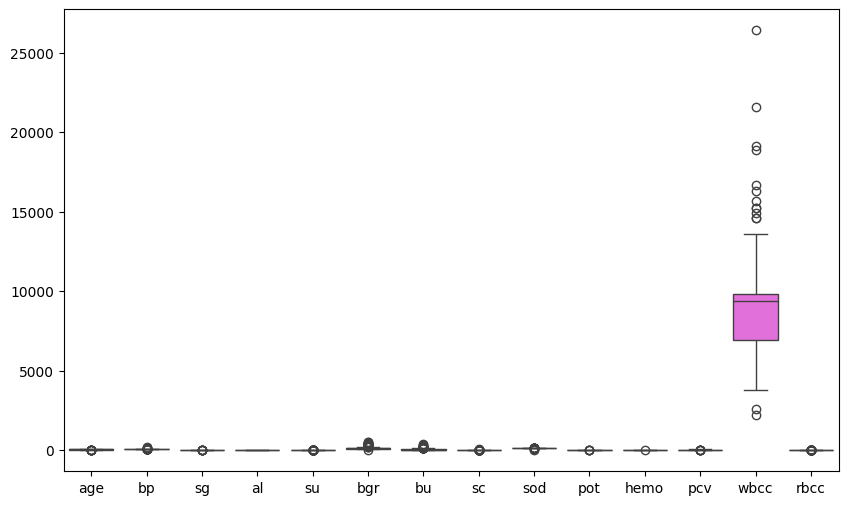

In [46]:
plt.figure(figsize=(10,6))
sb.boxplot(df)
plt.show()

In [47]:
# outlier count
for col in df.select_dtypes(include=["Int64", "Float64"]):
    size = df.shape[0]
    q1 = df[col].quantile(.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"Total outliers of {col}: {len(outliers)}")
    print(f"Percentage of Outliers (out of {size}): {round((len(outliers)/size)*100, 2)}%")
    print()

Total outliers of age: 10
Percentage of Outliers (out of 399): 2.51%

Total outliers of bp: 36
Percentage of Outliers (out of 399): 9.02%

Total outliers of sg: 7
Percentage of Outliers (out of 399): 1.75%

Total outliers of al: 0
Percentage of Outliers (out of 399): 0.0%

Total outliers of su: 61
Percentage of Outliers (out of 399): 15.29%

Total outliers of bgr: 51
Percentage of Outliers (out of 399): 12.78%

Total outliers of bu: 39
Percentage of Outliers (out of 399): 9.77%

Total outliers of sc: 53
Percentage of Outliers (out of 399): 13.28%

Total outliers of sod: 18
Percentage of Outliers (out of 399): 4.51%

Total outliers of pot: 4
Percentage of Outliers (out of 399): 1.0%

Total outliers of hemo: 1
Percentage of Outliers (out of 399): 0.25%

Total outliers of pcv: 6
Percentage of Outliers (out of 399): 1.5%

Total outliers of wbcc: 14
Percentage of Outliers (out of 399): 3.51%

Total outliers of rbcc: 51
Percentage of Outliers (out of 399): 12.78%



In [600]:
# for col in df.select_dtypes(include=["Int64", "Float64"]):
#     size = df.shape[0]
#     q1 = df[col].quantile(.25)
#     q3 = df[col].quantile(0.75)
#     iqr = q3 - q1
#     lower = q1 - 1.5 * iqr
#     upper = q3 + 1.5 * iqr

#     df = df[(df[col] < lower) | (df[col] > upper)]

In [601]:
df.shape

(399, 25)

In [602]:
df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,normal,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,normal,normal,notpresent,notpresent,99.0,...,38.0,6000.0,5.2,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,5.2,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


In [603]:
df.isna().sum()

age      0
bp       0
sg       0
al       0
su       0
rbc      0
pc       0
pcc      0
ba       0
bgr      0
bu       0
sc       0
sod      0
pot      0
hemo     0
pcv      0
wbcc     0
rbcc     0
htn      0
dm       0
cad      0
appet    0
pe       0
ane      0
class    0
dtype: int64

In [604]:
df.to_csv("chronic.csv", index=False)

In [50]:
obj = list(df.select_dtypes(include=["string"]).columns)
print(obj)


['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'class']


In [51]:
encoder = ce.OrdinalEncoder(obj)
df1 = pd.DataFrame(data = encoder.fit_transform(df), columns = df.columns)
df1

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,1,1,1,1,121.0,...,44.0,7800.0,5.2,1,1,1,1,1,1,1
1,7.0,50.0,1.020,4.0,0.0,1,1,1,1,99.0,...,38.0,6000.0,5.2,2,2,1,1,1,1,1
2,62.0,80.0,1.010,2.0,3.0,1,1,1,1,423.0,...,31.0,7500.0,5.2,2,1,1,2,1,2,1
3,48.0,70.0,1.005,4.0,0.0,1,2,2,1,117.0,...,32.0,6700.0,3.9,1,2,1,2,2,2,1
4,51.0,80.0,1.010,2.0,0.0,1,1,1,1,106.0,...,35.0,7300.0,4.6,2,2,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
394,55.0,80.0,1.020,0.0,0.0,1,1,1,1,140.0,...,47.0,6700.0,4.9,2,2,1,1,1,1,2
395,42.0,70.0,1.025,0.0,0.0,1,1,1,1,75.0,...,54.0,7800.0,6.2,2,2,1,1,1,1,2
396,12.0,80.0,1.020,0.0,0.0,1,1,1,1,100.0,...,49.0,6600.0,5.4,2,2,1,1,1,1,2
397,17.0,60.0,1.025,0.0,0.0,1,1,1,1,114.0,...,51.0,7200.0,5.9,2,2,1,1,1,1,2


In [52]:
df1.to_csv('C:/Users/balaj/OneDrive/Desktop/disease prediction models/good dataset/chronic_kidney.csv', index=False)

In [624]:
df1.drop('class', axis=1, inplace=True)

In [625]:
df1["class"] = df["class"]

In [626]:
df1

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,1,1,1,1,121.0,...,44.0,7800.0,5.2,1,1,1,1,1,1,ckd
1,7.0,50.0,1.020,4.0,0.0,1,1,1,1,99.0,...,38.0,6000.0,5.2,2,2,1,1,1,1,ckd
2,62.0,80.0,1.010,2.0,3.0,1,1,1,1,423.0,...,31.0,7500.0,5.2,2,1,1,2,1,2,ckd
3,48.0,70.0,1.005,4.0,0.0,1,2,2,1,117.0,...,32.0,6700.0,3.9,1,2,1,2,2,2,ckd
4,51.0,80.0,1.010,2.0,0.0,1,1,1,1,106.0,...,35.0,7300.0,4.6,2,2,1,1,1,1,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
394,55.0,80.0,1.020,0.0,0.0,1,1,1,1,140.0,...,47.0,6700.0,4.9,2,2,1,1,1,1,notckd
395,42.0,70.0,1.025,0.0,0.0,1,1,1,1,75.0,...,54.0,7800.0,6.2,2,2,1,1,1,1,notckd
396,12.0,80.0,1.020,0.0,0.0,1,1,1,1,100.0,...,49.0,6600.0,5.4,2,2,1,1,1,1,notckd
397,17.0,60.0,1.025,0.0,0.0,1,1,1,1,114.0,...,51.0,7200.0,5.9,2,2,1,1,1,1,notckd


In [4]:
import category_encoders as ce 

In [3]:
!pip install category_encoders

Defaulting to user installation because normal site-packages is not writeable
